In [67]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score

In [63]:
X_train2 = data = pd.read_pickle("Xtrain2.pkl")
Y_train2 = np.load("Ytrain2.npy")

print("Dataset Information\n")
print(f"Total: {len(data)} sequences, 14 patients\n")
print(f"Columns: {list(data.columns)}")

# Create table showing each patient's label
print("\nPatient labels and sequences table")
patient_info = data.groupby('Patient_Id').agg({
    'Exercise_Id': 'count',
    'Skeleton_Sequence': lambda x: x.iloc[0].shape[0]
}).rename(columns={'Exercise_Id': 'N_Sequences', 'Skeleton_Sequence': 'Duration_frames'})
patient_info['Label'] = Y_train2
patient_info['Left/Right'] = patient_info['Label'].map({0: 'Left', 1: 'Right'})
print(patient_info,"\n")

print(f"                  Left (0): {(Y_train2 == 0).sum()} patients")
print(f"                  Right (1): {(Y_train2 == 1).sum()} patients")


Dataset Information

Total: 444 sequences, 14 patients

Columns: ['Patient_Id', 'Exercise_Id', 'Skeleton_Sequence']

Patient labels and sequences table
            N_Sequences  Duration_frames  Label Left/Right
Patient_Id                                                
1                    28              172      0       Left
2                    25              103      0       Left
3                    33              123      0       Left
4                    31              241      0       Left
5                    31               83      1      Right
6                    37              122      1      Right
7                    34              130      1      Right
8                    36               97      0       Left
9                    32              249      0       Left
10                   31              131      0       Left
11                   30               71      0       Left
12                   32              101      1      Right
13                   3

In [ ]:
#agregation with vectors 
sequences = data['Skeleton_Sequence'].apply(lambda seq: np.mean(seq, axis=0))

data['Seq_sek'] = sequences
X_patient = data.groupby('Patient_Id')['Seq_sek'].apply(lambda seqs: np.mean(np.stack(seqs), axis=0))
X_patient = np.stack(X_patient.values)
y_patient = Y_train2

print(f"  Final shape: {X_patient.shape}")


  Final shape: (14, 66)


In [77]:
# Model Training with LOPO CV
# ---------------------------



pipelines = {
    'Random Forest': Pipeline([('scaler', StandardScaler()), ('model', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'SVM RBF': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))]),
    'MLP': Pipeline([('scaler', StandardScaler()), ('model', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42))])
}

# Train and evaluate each model with LOPO
results = {}
for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_patient, y_patient, cv=LeaveOneOut())
    results[name] = balanced_accuracy_score(y_patient, y_pred)
    print(f"{name:15s}: Balanced Accuracy = {results[name]:.4f}")




Random Forest  : Balanced Accuracy = 0.5333
SVM RBF        : Balanced Accuracy = 0.5889
MLP            : Balanced Accuracy = 0.5222


In [74]:
# Final Model Training and Prediction Example
# ----------------------------------------------

# Train the best model (SVM RBF) on all training data


best_model.fit(X_patient, y_patient)



# Example: Predictions on training data (demonstration)
predictions = best_model.predict(X_patient)

# Save the model
#joblib.dump(final_model, '')


AttributeError: 'str' object has no attribute 'fit'


Skeleton Visualization: Left vs Right Stroke Comparison
----------------------------------------------------------------------

Comparing Patient 1 (Left) vs Patient 5 (Right) - Exercise E2
Patient 1: 224 frames
Patient 5: 86 frames


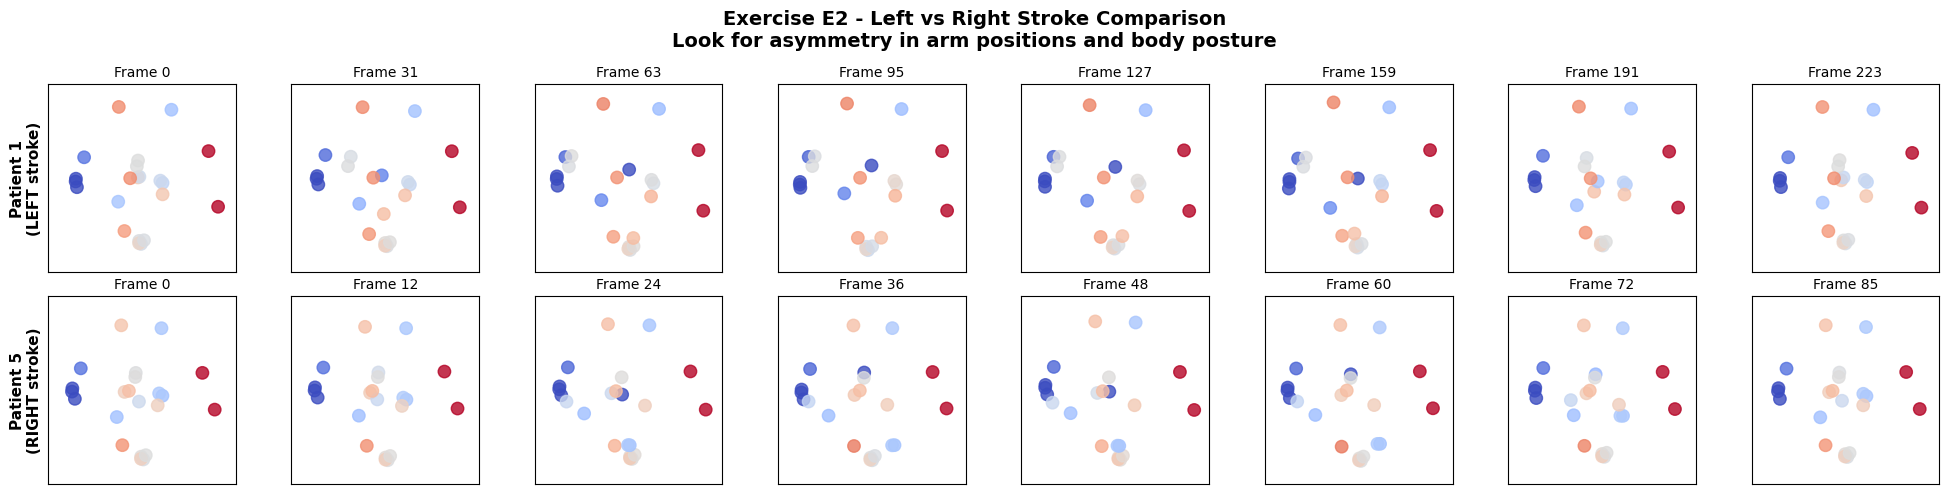


Average posture (features used by the model):


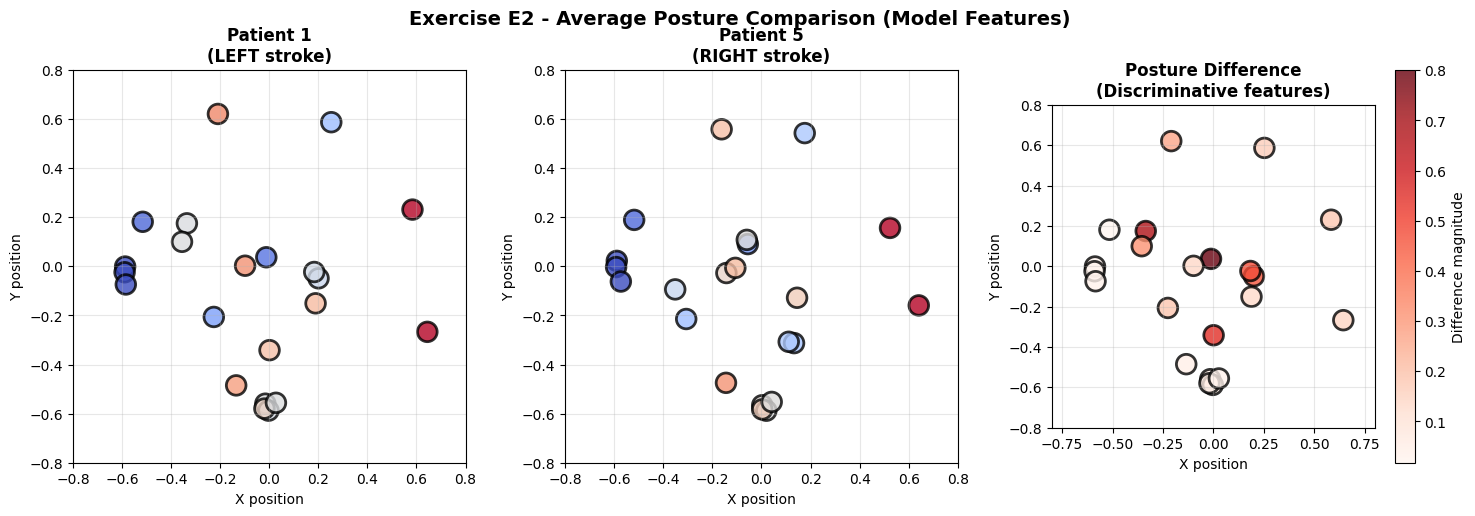

In [65]:
# SKELETON VISUALIZATION: Compare Left vs Right stroke patients
# ----------------------------------------------------------------------------

def plot_skeleton_comparison(seq_left, seq_right, patient_left, patient_right, exercise_id, n_frames=8):
    """
    Compare skeleton sequences from Left and Right patients side-by-side
    Highlights asymmetry differences caused by stroke
    """
    T_left = seq_left.shape[0]
    T_right = seq_right.shape[0]
    
    # Select evenly spaced frames
    frame_indices_left = np.linspace(0, T_left-1, n_frames, dtype=int)
    frame_indices_right = np.linspace(0, T_right-1, n_frames, dtype=int)
    
    fig, axes = plt.subplots(2, n_frames, figsize=(20, 5))
    
    for idx in range(n_frames):
        # Left patient
        ax_left = axes[0, idx]
        frame_left = seq_left[frame_indices_left[idx]]
        x_left = frame_left[0::3]
        y_left = frame_left[1::3]
        z_left = frame_left[2::3]
        
        ax_left.scatter(x_left, y_left, c=z_left, cmap='coolwarm', s=80, alpha=0.8, vmin=-0.5, vmax=0.5)
        ax_left.set_title(f'Frame {frame_indices_left[idx]}', fontsize=10)
        ax_left.set_xlim([-0.8, 0.8])
        ax_left.set_ylim([-0.8, 0.8])
        ax_left.set_aspect('equal')
        ax_left.grid(True, alpha=0.2)
        ax_left.set_xticks([])
        ax_left.set_yticks([])
        
        if idx == 0:
            ax_left.set_ylabel(f'Patient {patient_left}\n(LEFT stroke)', fontsize=11, fontweight='bold')
        
        # Right patient
        ax_right = axes[1, idx]
        frame_right = seq_right[frame_indices_right[idx]]
        x_right = frame_right[0::3]
        y_right = frame_right[1::3]
        z_right = frame_right[2::3]
        
        ax_right.scatter(x_right, y_right, c=z_right, cmap='coolwarm', s=80, alpha=0.8, vmin=-0.5, vmax=0.5)
        ax_right.set_title(f'Frame {frame_indices_right[idx]}', fontsize=10)
        ax_right.set_xlim([-0.8, 0.8])
        ax_right.set_ylim([-0.8, 0.8])
        ax_right.set_aspect('equal')
        ax_right.grid(True, alpha=0.2)
        ax_right.set_xticks([])
        ax_right.set_yticks([])
        
        if idx == 0:
            ax_right.set_ylabel(f'Patient {patient_right}\n(RIGHT stroke)', fontsize=11, fontweight='bold')
    
    plt.suptitle(f'Exercise {exercise_id} - Left vs Right Stroke Comparison\nLook for asymmetry in arm positions and body posture', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_average_posture_comparison(seq_left, seq_right, patient_left, patient_right, exercise_id):
    """
    Compare average posture between Left and Right stroke patients
    Shows the aggregated features that the model uses for classification
    """
    # Compute average posture over time (temporal mean)
    avg_posture_left = np.mean(seq_left, axis=0)
    avg_posture_right = np.mean(seq_right, axis=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Left patient average posture
    ax1 = axes[0]
    x_left = avg_posture_left[0::3]
    y_left = avg_posture_left[1::3]
    z_left = avg_posture_left[2::3]
    ax1.scatter(x_left, y_left, c=z_left, cmap='coolwarm', s=200, alpha=0.8, vmin=-0.5, vmax=0.5, edgecolors='black', linewidth=2)
    ax1.set_title(f'Patient {patient_left}\n(LEFT stroke)', fontsize=12, fontweight='bold')
    ax1.set_xlim([-0.8, 0.8])
    ax1.set_ylim([-0.8, 0.8])
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X position')
    ax1.set_ylabel('Y position')
    
    # Right patient average posture
    ax2 = axes[1]
    x_right = avg_posture_right[0::3]
    y_right = avg_posture_right[1::3]
    z_right = avg_posture_right[2::3]
    ax2.scatter(x_right, y_right, c=z_right, cmap='coolwarm', s=200, alpha=0.8, vmin=-0.5, vmax=0.5, edgecolors='black', linewidth=2)
    ax2.set_title(f'Patient {patient_right}\n(RIGHT stroke)', fontsize=12, fontweight='bold')
    ax2.set_xlim([-0.8, 0.8])
    ax2.set_ylim([-0.8, 0.8])
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('X position')
    ax2.set_ylabel('Y position')
    
    # Difference map (discriminative features)
    ax3 = axes[2]
    diff = np.abs(avg_posture_left - avg_posture_right)
    x_diff = diff[0::3]
    y_diff = diff[1::3]
    z_diff = diff[2::3]
    total_diff = x_diff + y_diff + z_diff
    
    scatter = ax3.scatter(x_left, y_left, c=total_diff, cmap='Reds', s=200, alpha=0.8, edgecolors='black', linewidth=2)
    ax3.set_title('Posture Difference\n(Discriminative features)', fontsize=12, fontweight='bold')
    ax3.set_xlim([-0.8, 0.8])
    ax3.set_ylim([-0.8, 0.8])
    ax3.set_aspect('equal')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlabel('X position')
    ax3.set_ylabel('Y position')
    plt.colorbar(scatter, ax=ax3, label='Difference magnitude')
    
    plt.suptitle(f'Exercise {exercise_id} - Average Posture Comparison (Model Features)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize comparison between Left and Right patients
print("\nSkeleton Visualization: Left vs Right Stroke Comparison")
print("-"*70)

# Select patients and exercise for comparison
# Let's use Exercise E2 (often shows more upper body asymmetry)
left_sequences = data[data['Patient_Id'] == 1]
right_sequences = data[data['Patient_Id'] == 5]

# Find E2 exercise for both patients
left_e2 = left_sequences[left_sequences['Exercise_Id'] == 'E2'].iloc[0] if len(left_sequences[left_sequences['Exercise_Id'] == 'E2']) > 0 else left_sequences.iloc[0]
right_e2 = right_sequences[right_sequences['Exercise_Id'] == 'E2'].iloc[0] if len(right_sequences[right_sequences['Exercise_Id'] == 'E2']) > 0 else right_sequences.iloc[0]

print(f"\nComparing Patient 1 (Left) vs Patient 5 (Right) - Exercise {left_e2['Exercise_Id']}")
print(f"Patient 1: {left_e2['Skeleton_Sequence'].shape[0]} frames")
print(f"Patient 5: {right_e2['Skeleton_Sequence'].shape[0]} frames")

# Frame-by-frame comparison
plot_skeleton_comparison(left_e2['Skeleton_Sequence'], right_e2['Skeleton_Sequence'], 
                        1, 5, left_e2['Exercise_Id'])

# Average posture comparison (what the model sees)
print("\nAverage posture (features used by the model):")
plot_average_posture_comparison(left_e2['Skeleton_Sequence'], right_e2['Skeleton_Sequence'], 
                               1, 5, left_e2['Exercise_Id'])
